In [1]:
import cartopy.crs as ccrs
import geopandas as gpd
import IPython
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import xarray as xr

from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
from scipy.spatial import cKDTree

In [2]:
pd.options.display.float_format = "{:.2f}".format
%precision 1

'%.1f'

In [3]:
# a folder where PyPSA-Zambia project is located
pypsa_zm_path = ""
resources_subfolder = "pypsa-zambia/resources/validation_dispatch_zambia_2024/"

data_folder = "runoff/"
grdc_folder = "runoff/GRDC/"

We are interested in a model region which correspomds to our mini-grid which has the following coordinates:

## Power inputs data

In [4]:
power_data_dir = pypsa_zm_path + resources_subfolder
ppl_fl = "powerplants.csv"

In [5]:
power_data_dir = Path(pypsa_zm_path, resources_subfolder)
ppl_fl = "powerplants.csv"

In [6]:
ppl_df = pd.read_csv(Path(pypsa_zm_path, resources_subfolder, ppl_fl))

## Observations data

In [7]:
grdc_csv = Path(grdc_folder, "GRDC-Daily.nc")
grdc_df = xr.open_dataset(grdc_csv)

In [8]:
grdc_df

<xarray.Dataset> Size: 7MB
Dimensions:              (time: 23727, id: 72)
Coordinates:
  * time                 (time) datetime64[ns] 190kB 1941-01-15 ... 2005-12-31
  * id                   (id) int64 576B 1547100 1547200 ... 1591810 1591820
Data variables:
    runoff_mean          (time, id) float32 7MB ...
    area                 (id) float32 288B ...
    country              (id) <U2 576B ...
    geo_x                (id) float32 288B ...
    geo_y                (id) float32 288B ...
    geo_z                (id) float32 288B ...
    owneroforiginaldata  (id) <U85 24kB ...
    river_name           (id) <U13 4kB ...
    station_name         (id) <U37 11kB ...
    timezone             (id) float32 288B ...
Attributes:
    title:          Mean daily discharge (Q)
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Download from GRDC Database, 08/04/2026
    missing_value:  -999.000

In [9]:
grdc_df["station_name"].values

array(['CHUNGA RANCH', 'NSAMA', 'CHIPILI', 'NEAR CHIBOTE',
       'KASAMA/LUWINGU ROAD BRIDGE (60773250)', 'CHEMBE FERRY',
       'GREEN WATER FALLS', 'MWENDAKASHIBA', 'KAPUMA FALLS',
       'NTUMBACHUSHI FALLS', 'OLD PONTOON', 'CHANDAWAYAYA',
       'MBESUMA PONTOON (60773245)', 'MPIKA/KASAMA ROAD BRIDGE',
       'SHIWA NGANDU (60773275)', 'PUMP HOUSE', 'LWITIKILA FALLS',
       'MILIMA PUMP HOUSE', 'KALUNGU (60773235)', 'MUNGWI SCHOOL',
       'NAKONDE DAM SITE (60773230)', 'MPIKA ROAD BRIDGE', 'KESO FALLS',
       'KAMBOLE (60773105)', 'BELOW LAKE CHILA', 'SENANGA (60370001)',
       'LUKULU (60370030)', 'KALENI HILL ROAD BRIDGE', 'CHIVATA VILLAGE',
       'IKELENGE', 'KABOMPO PONTOON (60380051)', 'MANYINGA', 'SACHIBONDO',
       'MUTANDA MISSION (60334501)', 'BELOW KASEMPA (60334620)',
       'KALOMO DAM SITE (60352030)', 'KIPUSHI ROAD (60334005)',
       'KASAKA (60334977)', 'NYIMBA', 'ITEZHI-TEZHI',
       'KAFUE HOOK BRIDGE (60334669)', 'MSWEBI',
       'MACHIYA FERRY (60334280)

In [10]:
grdc_df["river_name"].values

array(['KALUNGU', 'MWAMBESHI', 'LUFUBU', 'LUFUBU', 'LUKULU', 'LUAPULA',
       'LUFUBU', 'LUONGO', 'MUTOTOSHI', 'NGONA', 'CHAMBESHI', 'CHAMBESHI',
       'CHAMBESHI', 'KANCHIBYA', 'MANSHA', 'LUKUPA', 'LWITIKILA',
       'MILIMA', 'KALUNGU', 'MUNGU', 'NAKONDE', 'LWITIKILA', 'LUFUBU',
       'LUNZUA', 'LUCHECHE', 'ZAMBEZI RIVER', 'ZAMBEZI RIVER',
       'ZAMBEZI RIVER', 'MACONDO', 'LUINGA', 'KABOMPO', 'MANYINGA',
       'LUAKELA', 'MUTANDA', 'LUFUPA', 'KALOMO', 'KAFUE', 'KAFUE',
       'KAFUE', 'KAFUE', 'KAFUE', 'KAFUE', 'KAFUE', 'KAFUE', 'KALEYA',
       'KALEYA', 'KALEYA', 'MAGOYE', 'MWEMBESHI', 'LUNGA', 'LUSWISHI',
       'LUSWISHI', 'NANGOMA', 'MACONDO', 'KAFUE', 'KAFUE', 'KAFUE',
       'KAFUBU', 'KAFUBU', 'KAFUE', 'KAFUE', 'KAFUE', 'MUCHINDAMU',
       'BALUBA', 'KAFULAFUTA', 'LUSIWASI', 'KATETE', 'MULUNGUSHI',
       'LUANGWA', 'CHONGWE', 'NGWERERE', 'LUANGUINGA'], dtype='<U13')

### Scan data quality

In [11]:
def extract_grdc_ts(grdc_df, station_name):
    df = grdc_df.copy(deep=True)
    res = (
        df["runoff_mean"]
        .where(df["station_name"] == station_name, drop=True)
        .isel(id=0)
    )
    return res

In [12]:
st_names_list = grdc_df["station_name"].values.tolist()

A plot for a signle station:

for st in st_names_list[0]:
    fig, ax = plt.subplots(figsize=(8, 4))
    st_df = extract_grdc_ts(grdc_df=grdc_df, station_name=st)
    st_df.plot(ax=ax)
    ax.set_title(f"{st}")
    pdf.savefig(fig)
    plt.close(fig)


Plots for all the stations placed in a pdf

In [13]:
with PdfPages("grds_ts.pdf") as pdf:
    for st in st_names_list:
        fig, ax = plt.subplots(figsize=(8, 4))
        st_df = extract_grdc_ts(grdc_df=grdc_df, station_name=st)
        st_df.plot(ax=ax)
        ax.set_title(f"{st}")
        pdf.savefig(fig)
        plt.close(fig)


## GloFAS data

In [14]:
glofas_2013_path = Path(data_folder, "GloFAS", "zm-2013-glofas.nc")
glofas_2001_path = Path(data_folder, "GloFAS", "zm-2001-glofas.nc")
glofas_2002_path = Path(data_folder, "GloFAS", "zm-2002-glofas.nc")

glofas_2013 = xr.open_dataset(glofas_2013_path)
glofas_2001 = xr.open_dataset(glofas_2001_path)
glofas_2002 = xr.open_dataset(glofas_2002_path)

In [15]:
glofas_2013

<xarray.Dataset> Size: 79MB
Dimensions:     (valid_time: 365, latitude: 216, longitude: 252)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2013-01-02 ... 2014-01-01
    surface     float64 8B ...
  * latitude    (latitude) float64 2kB -7.825 -7.875 -7.925 ... -18.53 -18.57
  * longitude   (longitude) float64 2kB 21.62 21.68 21.73 ... 34.08 34.13 34.17
Data variables:
    dis24       (valid_time, latitude, longitude) float32 79MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-12T21:04 GRIB to CDM+CF via cfgrib-0.9.1...

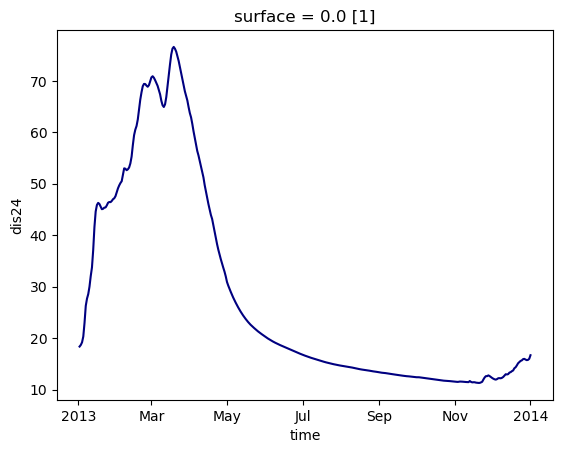

In [16]:
glofas_2013["dis24"].mean(dim=['latitude', 'longitude']).plot(color="navy")

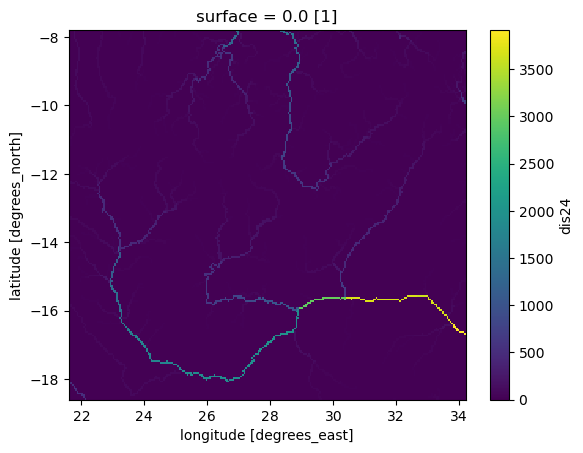

In [17]:
glofas_2013["dis24"].mean(dim=["valid_time"]).plot()

### Spatial structure of hydropower

In [18]:
ppl_hydro_df = ppl_df.query("Fueltype=='Hydro'")

In [19]:
def truncate_colormap(cmap_name, minval=0.0, maxval=1.0, n=256):
    cmap = plt.get_cmap(cmap_name)
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc({cmap_name},{minval:.2f},{maxval:.2f})",
        new_colors
    )

cmap_saturated_blues = truncate_colormap("Blues", minval=0.25, maxval=1.0)
cmap_blue_ocean = truncate_colormap("ocean_r", minval=0.05, maxval=0.75)
cmap_bright_gnbu = truncate_colormap("GnBu", minval=0.5, maxval=1.0)

In [20]:
ppl_hydro_df[["Name", "lat", "lon", "Capacity"]]

,Name,lat,lon,Capacity
0,Itezhi Tezhi,-15.76,26.02,120.00
1,Kafue Gorge Upper,-15.81,28.42,990.00
2,Kariba North Bank,-16.52,28.76,720.00
3,Victoria Falls,-17.93,25.86,108.00
5,Lusiwasi Zambia,-12.99,30.86,12.00
7,Mulungushi Dam Zambia,-14.74,28.84,32.00
16,Kafue Gorge Lower,-15.90,28.56,750.00
17,Kariba North Bank Extension,-16.52,28.76,360.00
18,Lunzua,-8.90,31.16,14.80
19,Lusiwasi Upper,-12.99,30.86,15.00


Select a few power plants for a more detailed examination

In [21]:
ppl_hydro_selected_df = ppl_hydro_df.query(
    "(lat>-17)&(lat<-15.5)&(lon>28)&(lon<29)"
)[["Name", "lat", "lon", "Capacity"]]

In [22]:
ppl_hydro_selected_df

,Name,lat,lon,Capacity
1,Kafue Gorge Upper,-15.81,28.42,990.00
2,Kariba North Bank,-16.52,28.76,720.00
16,Kafue Gorge Lower,-15.90,28.56,750.00
17,Kariba North Bank Extension,-16.52,28.76,360.00


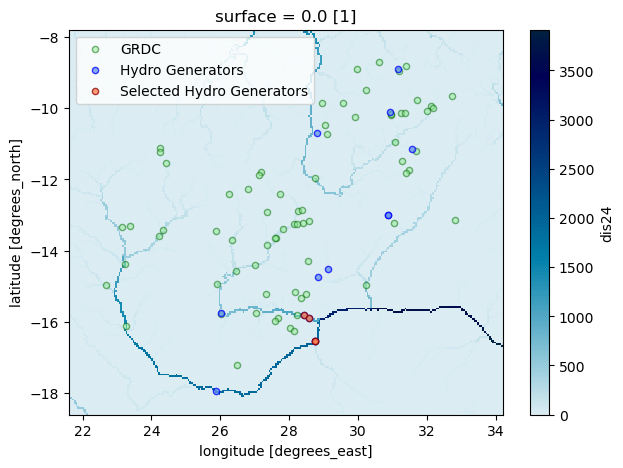

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
(
    glofas_2013["dis24"]
    .mean(dim=["valid_time"])
    .plot(ax=ax, cmap=cmap_blue_ocean, alpha=1)
    #.plot(ax=ax, cmap=cmap_saturated_blues)
    #.plot(ax=ax, cmap=cmap_bright_gnbu, alpha=0.5)
)
ax.scatter(
    grdc_df["geo_x"].values.tolist(),
    grdc_df["geo_y"].values.tolist(),
    marker="o",
    s=20,
    facecolor="lightgreen",
    edgecolor="darkgreen",
    alpha=0.5,
    label="GRDC",
)
ax.scatter(
    ppl_hydro_df["lon"],
    ppl_hydro_df["lat"],
    marker="o",
    s=20,
    facecolor="cornflowerblue",
    edgecolor="blue",
    alpha=0.75,
    label="Hydro Generators",    
)
ax.scatter(
    ppl_hydro_selected_df["lon"],
    ppl_hydro_selected_df["lat"],
    marker="o",
    s=20,
    facecolor="coral",
    edgecolor="darkred",
    alpha=0.75,
    label="Selected Hydro Generators",    
)
ax.legend()

## Reanalysis data

### Read data

In [24]:
hydro_path = Path(pypsa_zm_path, resources_subfolder, "renewable_profiles/profile_hydro.nc")
hydro = xr.open_dataset(hydro_path)

In [25]:
hydro

<xarray.Dataset> Size: 1MB
Dimensions:  (plant: 14, time: 8760)
Coordinates:
  * plant    (plant) int64 112B 0 1 2 3 5 7 16 17 18 19 20 21 22 23
  * time     (time) datetime64[ns] 70kB 2013-01-01 ... 2013-12-31T23:00:00
Data variables:
    inflow   (plant, time) float64 981kB ...

Extract coordinates to inflow time-series in the hydro profile:

In [26]:
ppl_hydro_idx_list = hydro["plant"].values.tolist()

In [27]:
ppl_hydro_idx_list

[0, 1, 2, 3, 5, 7, 16, 17, 18, 19, 20, 21, 22, 23]

#### Demo for a singe station

In [28]:
pl_idx = ppl_hydro_idx_list[0]

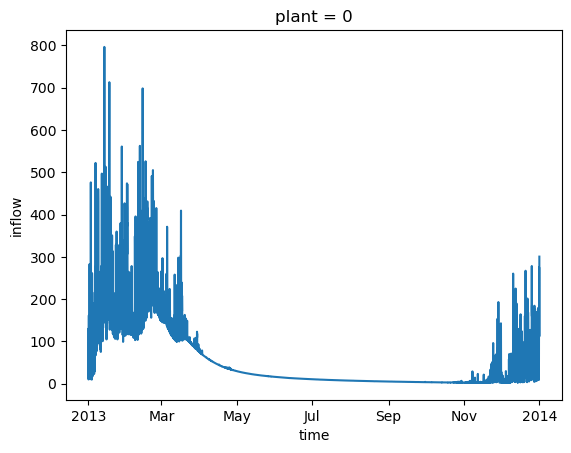

In [29]:
hydro.where(hydro["plant"] == pl_idx, drop=True)["inflow"].plot()

In [30]:
ppl_hydro_df.iloc[pl_idx]["lon"], ppl_hydro_df.iloc[pl_idx]["lat"]

(26.0, -15.8)

In [31]:
dx = 1 # 0.05 is step if GloFAS grid
grdc_ppl_i = (
    grdc_df.where(
        (grdc_df["geo_y"] > ppl_hydro_df.iloc[pl_idx]["lat"] - dx) &
        (grdc_df["geo_y"] < ppl_hydro_df.iloc[pl_idx]["lat"] + dx) &
        (grdc_df["geo_x"] > ppl_hydro_df.iloc[pl_idx]["lon"] - dx) &
        (grdc_df["geo_x"] < ppl_hydro_df.iloc[pl_idx]["lon"] + dx),        
        drop=True,
    )
)

In [32]:
grdc_ppl_i

<xarray.Dataset> Size: 380kB
Dimensions:              (time: 23727, id: 2)
Coordinates:
  * time                 (time) datetime64[ns] 190kB 1941-01-15 ... 2005-12-31
  * id                   (id) int64 16B 1591403 1591404
Data variables:
    runoff_mean          (time, id) float32 190kB nan nan nan ... nan 189.3
    area                 (id) float32 8B 1.057e+05 9.624e+04
    country              (id) object 16B 'ZM' 'ZM'
    geo_x                (id) float32 8B 26.02 25.92
    geo_y                (id) float32 8B -15.77 -14.93
    geo_z                (id) float32 8B -999.0 -999.0
    owneroforiginaldata  (id) object 16B 'Zambia - Department of Water Affair...
    river_name           (id) object 16B 'KAFUE' 'KAFUE'
    station_name         (id) object 16B 'ITEZHI-TEZHI' 'KAFUE HOOK BRIDGE (6...
    timezone             (id) float32 8B 2.0 2.0
Attributes:
    title:          Mean daily discharge (Q)
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Download from GRDC Database, 08/04/2026
    missing_value:  -999.000

### Validation (GRDC vs GloFAS)

Makes sense only for years which are present in GRDC data

In [ ]:
#grdc_year = 2001
grdc_ppl_i = (
    grdc_ppl_i
    .where(
        grdc_ppl_i["station_name"] == "KAFUE HOOK BRIDGE (60334669)",
        drop=True,
    )
)

### Validation (GloFAS vs atlite)

In [35]:
def extract_grdc_year(grdc_df, year):
    """
    Subset GRDC dataset for a selected station by a year of interest
    """    
    res = (
        grdc_ppl_i
        .where(
            (grdc_ppl_i.time.dt.year >= year) & 
            (grdc_ppl_i.time.dt.year <= year),
            drop=True,
        )
    )
    return res

def extract_glofas_loc(glofas_YYYY, hydro_ppl_df=ppl_hydro_df, i_ppl=0, dx=0.05):
    """
    Subset an annual GloFAS dataset for a selected station
    """     
    res = glofas_YYYY.where(
        (glofas_YYYY["latitude"] > hydro_ppl_df.iloc[i_ppl]["lat"] - dx) &
        (glofas_YYYY["latitude"] < hydro_ppl_df.iloc[i_ppl]["lat"] + dx) &
        (glofas_YYYY["longitude"] > hydro_ppl_df.iloc[i_ppl]["lon"] - dx) &
        (glofas_YYYY["longitude"] < hydro_ppl_df.iloc[i_ppl]["lon"] + dx),        
        drop=True,
    )
    return res

In [36]:
grdc_2001_ppl_i = extract_grdc_year(grdc_ppl_i, 2001)
grdc_2002_ppl_i = extract_grdc_year(grdc_ppl_i, 2002)
grdc_2013_ppl_i = extract_grdc_year(grdc_ppl_i, 2013)

In [37]:
# Validate Kafue ppl
i_valid = 0

glofas_2001_valid_ppl_i = extract_glofas_loc(
    glofas_2001,
    hydro_ppl_df=ppl_hydro_df,
    i_ppl=i_valid
)
glofas_2002_valid_ppl_i = extract_glofas_loc(
    glofas_2002,
    hydro_ppl_df=ppl_hydro_df,
    i_ppl=i_valid
)
glofas_2013_valid_ppl_i = extract_glofas_loc(
    glofas_2013,
    hydro_ppl_df=ppl_hydro_df,
    i_ppl=i_valid
)

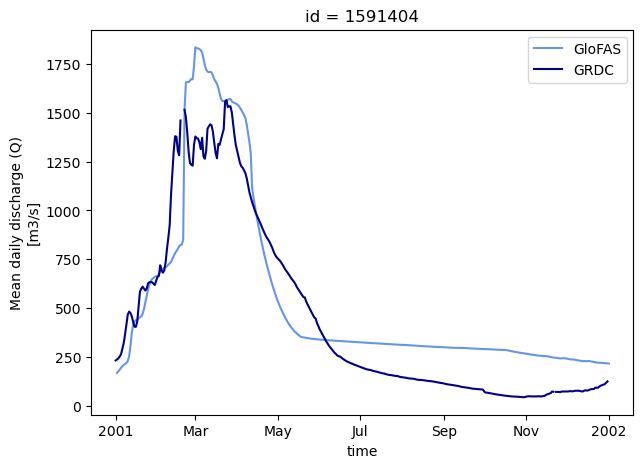

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))
(
    glofas_2001_valid_ppl_i.mean(dim=["latitude", "longitude"])["dis24"]
    .plot(ax=ax, color="cornflowerblue", label="GloFAS")
)
(
    grdc_2001_ppl_i["runoff_mean"].plot(ax=ax, color="darkblue", label="GRDC")
)
ax.legend()

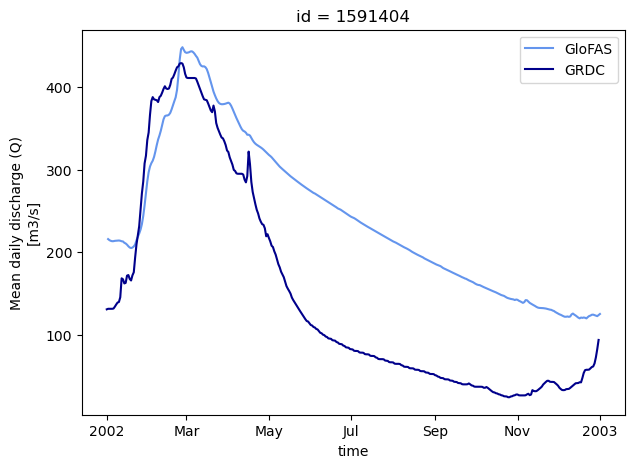

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
(
    glofas_2002_valid_ppl_i.mean(dim=["latitude", "longitude"])["dis24"]
    .plot(ax=ax, color="cornflowerblue", label="GloFAS")
)
(
    grdc_2002_ppl_i["runoff_mean"].plot(ax=ax, color="darkblue", label="GRDC")
)
ax.legend()

### Cross-validation (GloFAS vs atlite)

Works only for 2013 (demand profile restriction)

In [40]:
hydro_daily = (
    hydro
    .where(hydro["plant"] == pl_idx, drop=True)
    .resample(time="1D").mean()
)
hydro_monthly = (
    hydro
    .where(hydro["plant"] == pl_idx, drop=True)
    .resample(time="1m").mean()
)
glofas_monthly = (
    glofas_2013_valid_ppl_i
    .resample(valid_time="1m").mean()
)


~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [41]:
# Estimate a scaling coefficient
(
    glofas_2013_valid_ppl_i.mean(dim=["latitude", "longitude"])["dis24"].mean().values.tolist() / 
    hydro_monthly["inflow"].mean().values.tolist()
)

8.5

In [42]:
k_scale = 8.5

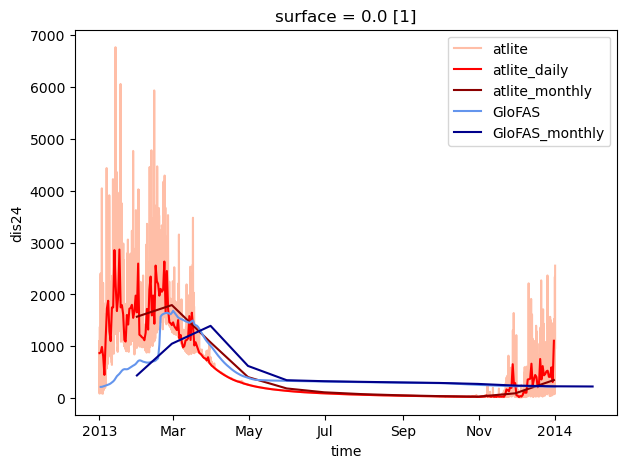

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
(
    (k_scale * hydro.where(hydro["plant"] == pl_idx, drop=True)["inflow"])
    .plot(ax=ax, color="coral", label="atlite", alpha=0.5)
)
(
    (k_scale * hydro_daily["inflow"])
    .plot(ax=ax, color="red", label="atlite_daily")
)
(
    (k_scale * hydro_monthly["inflow"])
    .plot(ax=ax, color="darkred", label="atlite_monthly")
)
(
    glofas_2013_valid_ppl_i.mean(dim=["latitude", "longitude"])["dis24"]
    .plot(ax=ax, color="cornflowerblue", label="GloFAS")
)
(
    glofas_monthly.mean(dim=["latitude", "longitude"])["dis24"]
    .plot(ax=ax, color="darkblue", label="GloFAS_monthly")
)
ax.legend()